# Fourier Neural Operator (FNO) in Neuromancer

This tutorial demonstrates the use of [FNOs](https://neuraloperator.github.io/dev/theory_guide/fno.html) for solving partial differential equations (PDEs) in the Neuromancer library.

Example inspiration: examples/PDEs/Part_1_PINN_DiffusionEquation.ipynb

We use a 16 x 16 training grid for training an FNO, and test the prediction on a 32 x 32 grid

This tutorial demonstrates the complete workflow of training a neural operator: 
1. Creating the diffusion equation dataset, wrapping in Neuromancer DictDataset
2. Creating an FNO model architecture 
3. Setting up `neuromancer.problem.Problem`, adding H1/L2 losses as `neuromancer.loss.PenaltyLoss`
4. Training the model with Neuromancer `Trainer`
5. Evaluating predictions and zero-shot super-resolution

<img src="https://neuraloperator.github.io/dev/_images/fourier_layer.jpg" width="600"> 

The Fourier layer just consists of three steps:
- Fourier transform $\mathcal{F}$
- Linear transform on the lower Fourier modes $\mathbf{R}$
- Inverse Fourier transform $\mathcal{F}^{-1}$



## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [1]:
# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")


In [2]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


## Problem Setup

original source: https://deepxde.readthedocs.io/en/latest/demos/pinn_forward/diffusion.1d.html

**Diffusion equation**

$$\frac{\partial y}{\partial t} =\frac{\partial^2 y}{\partial x^2}-e^{-t}(sin(\pi x)-\pi^2 sin(\pi x))$$

$$x\in[-1,1]$$
$$t\in[0,1]$$

**Initial Condition:**

$$y(x,0)=sin(\pi x)$$

**Boundary Conditions:**

$$y(-1,t)=0$$
$$y(1,t)=0$$

**Exact solution:**

$$y(x,t)=e^{-t}sin(\pi x)$$

### Generate data of the exact solution

In [3]:
# exact solution y(x,t)
def f_real(x, t):
    return torch.exp(-t) * (torch.sin(np.pi * x))


# define range of the space and time variables:
x_min = -1
x_max = 1
t_min = 0
t_max = 1

# define number of spatial and temporal points
total_points_x = 200
total_points_t = 100

# generate samples of x, t
x = torch.linspace(x_min, x_max, total_points_x).view(-1, 1)
t = torch.linspace(t_min, t_max, total_points_t).view(-1, 1)

# Create the mesh of x, t
X, T = torch.meshgrid(x.squeeze(1), t.squeeze(1), indexing="ij")

# Evaluate exact solution y(x,t) on the mesh
y_real = f_real(X, T)

# data shapes
print(x.shape, t.shape)
print(X.shape, T.shape, y_real.shape)

torch.Size([200, 1]) torch.Size([100, 1])
torch.Size([200, 100]) torch.Size([200, 100]) torch.Size([200, 100])


In [4]:
# min and max values of the PDE solution
ymin = y_real.min()
ymax = y_real.max()
print(ymin, ymax)

tensor(-1.0000) tensor(1.0000)


### Plot the exact solution

In [5]:
def plot3D(X, T, y):
    #     2D
    fig = plt.figure()
    ax1 = fig.add_subplot(121)
    cm = ax1.contourf(T.numpy(), X.numpy(), y.numpy(), 20, cmap="viridis")
    fig.colorbar(cm, ax=ax1)  # Add a colorbar to a plot
    ax1.set_title("y(x,t)")
    ax1.set_xlabel("t")
    ax1.set_ylabel("x")
    ax1.set_aspect("equal")
    #     3D
    ax2 = fig.add_subplot(122, projection="3d")
    ax2.plot_surface(T.numpy(), X.numpy(), y.numpy(), cmap="viridis")
    ax2.set_xlabel("t")
    ax2.set_ylabel("x")
    ax2.set_zlabel("y(x,t)")
    fig.tight_layout()

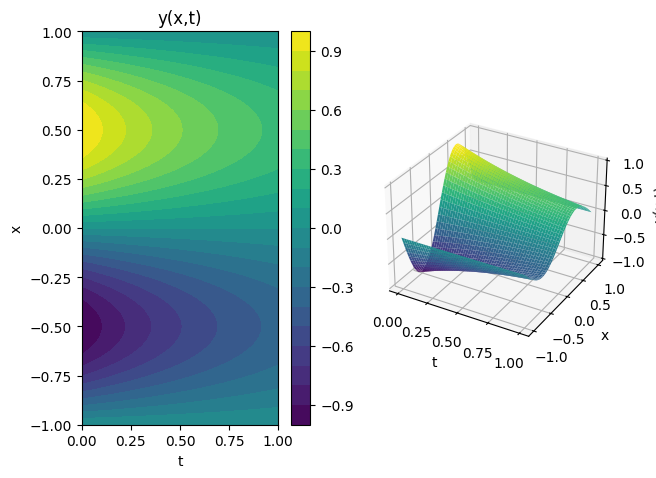

In [7]:
plot3D(X, T, y_real)

Insert training dataset for FNO, which is a sub-sampled 32x32 grid from the original 200X100 data

In [6]:
def make_fno_grid(nx, nt, requires_grad=False):
    x = torch.linspace(x_min, x_max, nx)
    t = torch.linspace(t_min, t_max, nt)
    X, T = torch.meshgrid(x, t, indexing="ij")
    Y = f_real(X, T)

    # FNO input/output grids: [batch_size, in_channels, nx, nt]
    xt_grid = torch.stack([X, T], dim=0).unsqueeze(0).float()
    y_grid = Y.unsqueeze(0).unsqueeze(0).float()

    # DeepONet Cartesian-product data (shared grid): m = nx * nt sensors
    coords = torch.stack([X, T], dim=-1).reshape(-1, 2)  # (m, dim_x)
    branch_inputs = Y.reshape(1, -1).float()  # (N=1, m)
    trunk_inputs = coords.unsqueeze(0).float()  # (N=1, m, dim_x)
    outputs = branch_inputs.clone()  # (N=1, m)

    if requires_grad:
        xt_grid.requires_grad_(True)
        branch_inputs.requires_grad_(True)
        trunk_inputs.requires_grad_(True)
    return xt_grid, y_grid, trunk_inputs, branch_inputs, outputs


In [7]:
train_nx, train_nt = 32, 32
test_nx, test_nt = 16, 16

(
    XT_train_grid,
    Y_train_grid,
    trunk_train,
    branch_train,
    outputs_train,
) = make_fno_grid(train_nx, train_nt, requires_grad=False)

(
    XT_test_grid,
    Y_test_grid,
    trunk_test,
    branch_test,
    outputs_test,
) = make_fno_grid(test_nx, test_nt, requires_grad=False)


### Visualise the training and testing grid. Takes a carterisan coordiante system

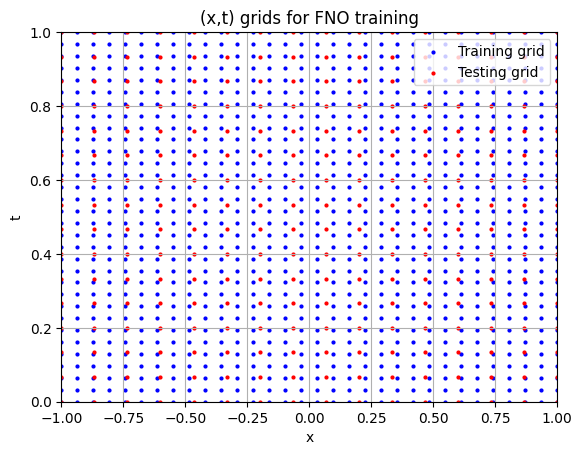

In [8]:
# visualize collocation points for 2D input space (x, t)

# --- Prepare Training Data ---
# Select the x and t coordinates (indices 0 and 1 in dim 1)
# and flatten the last two dimensions (nx * nt) into one vector.
# .squeeze() removes the batch dimension (size 1).
X_train_flat = XT_train_grid.squeeze(0)[0, :, :].flatten()
T_train_flat = XT_train_grid.squeeze(0)[1, :, :].flatten()

# --- Prepare Testing Data (assuming a similar structure) ---
X_test_flat = XT_test_grid.squeeze(0)[0, :, :].flatten()
T_test_flat = XT_test_grid.squeeze(0)[1, :, :].flatten()

# x-bounds: find the min/max ONLY in the testing x-coordinates
x_lb = torch.min(X_test_flat).item()
x_ub = torch.max(X_test_flat).item()

# t-bounds: find the min/max ONLY in the testing t-coordinates
t_lb = torch.min(T_test_flat).item()
t_ub = torch.max(T_test_flat).item()

# --- Plotting ---
plt.figure()
plt.scatter(
    X_train_flat.detach().numpy(),
    T_train_flat.detach().numpy(),
    s=4.0,
    c="blue",
    marker="o",
    label="Training grid",
)
plt.scatter(
    X_test_flat.detach().numpy(),
    T_test_flat.detach().numpy(),
    s=4.0,
    c="red",
    marker="o",
    label="Testing grid",
)

plt.title("(x,t) grids for FNO training")
# Assuming x_lb, x_ub, t_lb, t_ub are defined in your environment
plt.xlim(x_lb, x_ub)
plt.ylim(t_lb, t_ub)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("t")
plt.legend(loc="upper right")
plt.show()
# plt.show(block=True) # Usually only one plt.show() is needed
plt.show(block=True)

### Create Neuromancer datasets for FNO

In [10]:
from neuromancer.dataset import DictDataset

# turn on gradients for FNO/DeepONet data
XT_train_grid = XT_train_grid.to(device)
Y_train_grid = Y_train_grid.to(device)
branch_train = branch_train.to(device)
trunk_train = trunk_train.to(device)
outputs_train = outputs_train.to(device)
branch_test = branch_test.to(device)
trunk_test = trunk_test.to(device)
outputs_test = outputs_test.to(device)

# # Prepare FNO training and testing datasets
# train_ds_fno = DictDataset(
#     {"xt_grid": XT_train_grid, "y_grid": Y_train_grid}, name="fno_train"
# )

# train_loader_fno = torch.utils.data.DataLoader(
#     train_ds_fno, batch_size=1, collate_fn=train_ds_fno.collate_fn, shuffle=False
# )

# # testing grid
# test_ds_fno = DictDataset(
#     {"xt_grid": XT_test_grid, "y_grid": Y_test_grid}, name="fno_test"
# )
# test_loader_fno = torch.utils.data.DataLoader(
#     test_ds_fno, batch_size=1, collate_fn=test_ds_fno.collate_fn, shuffle=False
# )

# Cartesian-product DeepONet datasets (shared grid for every sample)
deeponet_train = DictDataset(
    {
        "branch_inputs": branch_train,
        "trunk_inputs": trunk_train,
        "outputs": outputs_train,
    },
    name="deeponet_train",
)

train_loader = torch.utils.data.DataLoader(
    deeponet_train, batch_size=1, collate_fn=deeponet_train.collate_fn, shuffle=False
)

deeponet_test = DictDataset(
    {
        "branch_inputs": branch_test,
        "trunk_inputs": trunk_test,
        "outputs": outputs_test,
    },
    name="deeponet_test",
)

test_loader = torch.utils.data.DataLoader(
    deeponet_test, batch_size=1, collate_fn=deeponet_test.collate_fn, shuffle=False
)


# Define DeepONet

The branch net is chosen as a fully connected neural network of size `[m, 32, p]`, where `p=32` and the trunk net is a fully connected neural network of size `[dim_x, 32, p]`, where `dim_x` is dimension i.e. 2

We use `dde.nn.DeepONet` to create the DeepONet directly for DeepXDE library. This is a generic DeepONet implementation needing a list of triple (function_sample, location, target_value)
(MLP architecture the same as [DeepXDE Poisson 1D example](https://deepxde.readthedocs.io/en/latest/demos/operator/poisson.1d.pideeponet.html))

In [ ]:
# DeepXDE library
import os

os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

# train_ds
sample = deeponet_train[0]
Nu = sample["branch_inputs"].shape[-1]  # numnber of sensors
dim_x = sample["trunk_inputs"].shape[-1]  # 1

print(Nu, dim_x)

p = 128
dde_DeepOnet = dde.nn.DeepONetCartesianProd(
    [Nu, 128, 128, p],
    [dim_x, 128, 128, p],
    activation="tanh",
    kernel_initializer="Glorot normal",
)


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


1024 2


In [13]:
from neuromancer.system import Node
from neuromancer.modules.operators import DeepXDEWrapper

dde_DeepOnet_wrapped = DeepXDEWrapper(
    model=dde_DeepOnet,
    is_cartesian=True,
)

node_dde_deeponet = Node(
    dde_DeepOnet_wrapped,
    ["branch_inputs", "trunk_inputs"],
    ["g"],
    name="dde_DeepOnet",
)
print(node_dde_deeponet)

dde_DeepOnet(branch_inputs, trunk_inputs) -> g


In [14]:
print("symbolic inputs  of the dde_DeepOnet_node:", node_dde_deeponet.input_keys)
print("symbolic outputs of the dde_DeepOnet_node:", node_dde_deeponet.output_keys)

symbolic inputs  of the dde_DeepOnet_node: ['branch_inputs', 'trunk_inputs']
symbolic outputs of the dde_DeepOnet_node: ['g']


In [15]:
# check device for train data
print(deeponet_train.datadict["branch_inputs"].device)
print(deeponet_train.datadict["trunk_inputs"].device)
# Check shapes match (Input vs Forward Pass Output)
print(f"Input branch shape: {deeponet_train.datadict['branch_inputs'].shape}")
print(f"Input trunk shape: {deeponet_train.datadict['trunk_inputs'].shape}")

cuda:0
cuda:0
Input branch shape: torch.Size([1, 1024])
Input trunk shape: torch.Size([1, 1024, 2])


In [21]:
# Forward pass
sample = deeponet_train.datadict
print(sample.keys())

node_out = node_dde_deeponet(sample)
print(f"Output shape: {node_out['g'].shape}")

dict_keys(['branch_inputs', 'trunk_inputs', 'outputs'])
Output shape: torch.Size([1, 1024])


# Generate H1 and L2 loss for loss evaluation 
We use H1 loss for training and L2 loss for evaluation H1 loss is particularly good for PDE problems as it penalizes both function values and gradients

## L2 norm

$$
\|y - y_h\|_{L^2(\Omega)}^2.
$$

## H1 norm

$$
\|y - y_h\|_{H^1(\Omega)}^2
=
\|y - y_h\|_{L^2(\Omega)}^2
+
\|y_x - y_{h,x}\|_{L^2(\Omega)}^2
+
\|y_t - y_{h,t}\|_{L^2(\Omega)}^2.
$$

### Formulate L2 loss, H1 loss

In [17]:
from neuromancer.modules.operators import LpLoss, H1Loss
from neuromancer.constraint import Loss  # wrapper for neuromancer

h1_loss_fn = H1Loss(d=2)
l2_loss_fn = LpLoss(d=2, p=2)

h1_obj = Loss(
    ["y_hat_fno", "y_grid"],
    lambda yhat, y: h1_loss_fn(
        yhat.squeeze(1), y.squeeze(1)
    ),  # [B, 1, Nx, Nt] -> [B, Nx, Nt]
    name="h1_loss_fn",
)

l2_obj = Loss(
    ["y_hat_fno", "y_grid"],
    lambda yhat, y: l2_loss_fn(
        yhat.squeeze(1), y.squeeze(1)
    ),  # [B, 1, Nx, Nt] -> [B, Nx, Nt]
    name="l2_loss_fn",
)

In [22]:
from neuromancer.constraint import variable

# Inputs from your datadict
y_true = variable("g")  # B x C x H x W
y_hat_fno = variable("outputs")  # B x C x H x W

# Finite forward differences (1D)
dx_hat = y_hat_fno[..., 1:] - y_hat_fno[..., :-1]
dx_true = y_true[..., 1:] - y_true[..., :-1]

In [23]:
from neuromancer.constraint import Objective

# Approach 2: Using Objective
residual_l2 = y_hat_fno - y_true
l2_obj = Objective(residual_l2**2, metric=torch.mean, name="l2_loss")

# Approach 2: Using Objective
residual_h1_dx = dx_hat - dx_true
h1_dx_obj = Objective(residual_h1_dx**2, metric=torch.mean, name="h1_dx_loss")

### Setup FNO problem and Trainer 

In [24]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

# aggregate list of objective terms and constraints
# objectives_fno = [l2_constraint, x_seminorm, t_seminorm]  # H1 loss for training FNO
objectives_fno = [l2_obj]  # L2 loss for training FNO
constraints_fno = []
# create constrained optimization loss
loss_fno = PenaltyLoss(objectives_fno, constraints_fno)

# construct the FNO supervised training problem
problem_fno = Problem(nodes=[node_dde_deeponet], loss=loss_fno, grad_inference=True)

### Show problem FNO

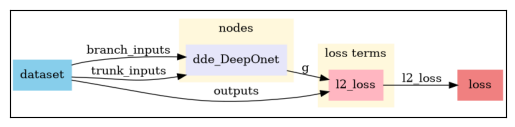

In [25]:
# Visualize the problem graph. Note: must have graphviz installed in the system
problem_fno.show()

### Train FNO purely data driven

In [28]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.Adam(problem_fno.parameters(), lr=0.001)
epochs = 50

#  Neuromancer trainer
trainer = Trainer(
    problem_fno.to(device),
    train_loader,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=10,
    train_metric="deeponet_train_loss",
    dev_metric="deeponet_train_loss",
    eval_metric="deeponet_train_loss",
    warmup=epochs,
    device=device,
)

In [29]:
# Train FNO
best_model = trainer.train()

# load best trained model
problem_fno.load_state_dict(best_model)

epoch: 0  deeponet_train_loss: 0.13602229952812195
epoch: 10  deeponet_train_loss: 0.23268726468086243
epoch: 20  deeponet_train_loss: 0.1934504508972168
epoch: 30  deeponet_train_loss: 0.1093214899301529
epoch: 40  deeponet_train_loss: 0.10306080430746078


<All keys matched successfully>

## Plots

In [34]:
#  make sure model and batch match devices
fno_out = problem_fno.nodes[0].to(device)  # device is cuda
batch = {k: v.to(device) for k, v in deeponet_test.datadict.items()}

with torch.no_grad():
    fno_model_out = fno_out(batch)

preds = fno_model_out["g"].cpu()
truth = deeponet_test.datadict["outputs"].cpu()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x256 and 1024x128)

In [32]:
# evaluate trained PINN on test data
fno_out = problem_fno.nodes[0]
y1 = fno_out(deeponet_test.datadict)

# arrange data for plotting on the test grid
y_fno = y1.reshape(shape=[test_nx, test_nt]).detach().cpu()

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)

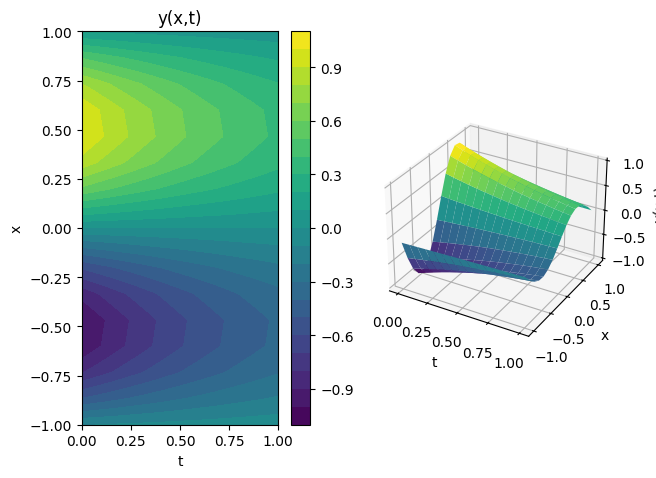

In [23]:
# plot FNO solution
# X-coordinates (index 0)
X_plot = XT_test_grid.squeeze(0)[0, :, :].detach().cpu()
# T-coordinates (index 1)
T_plot = XT_test_grid.squeeze(0)[1, :, :].detach().cpu()
plot3D(X_plot, T_plot, y_fno)

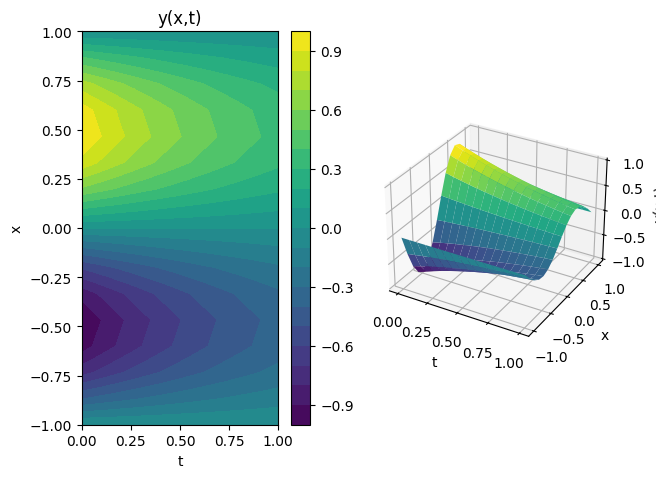

In [24]:
# plot exact PDE solution
Y_plot = Y_test_grid.squeeze(0).squeeze(0).detach().cpu()
plot3D(X_plot, T_plot, Y_plot)

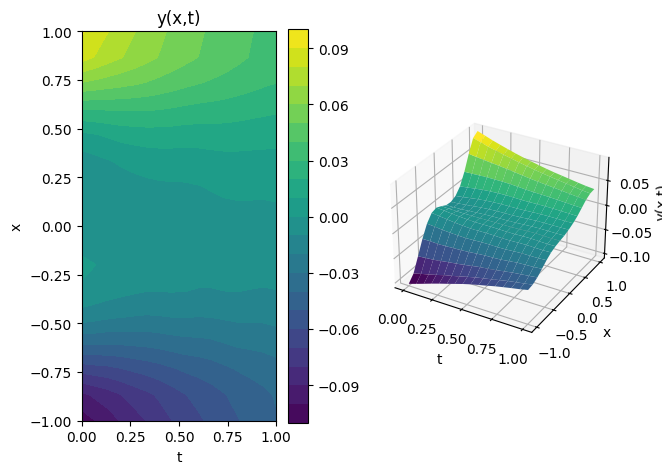

In [25]:
# plot residuals PINN - exact PDE
plot3D(X_plot, T_plot, y_fno - Y_plot)